In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
url = "https://raw.githubusercontent.com/AbrarYasir01/220140_SVM_KNN/refs/heads/main/Telco-Customer-Churn.txt"
df = pd.read_csv(url)

In [3]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [5]:
df = df.drop('customerID', axis=1)

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
imputer = SimpleImputer(strategy='median')
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']])

In [7]:
le = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    df[column] = le.fit_transform(df[column])

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [13]:
best_model = grid.best_estimator_

In [14]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [15]:
acc = accuracy_score(y_test,y_pred)
pre = precision_score(y_test,y_pred)
rec = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
auc = roc_auc_score(y_test,y_prob)

print("Accuracy:",acc)
print("Precision:",pre)
print("Recall:",rec)
print("F1 Score:",f1)
print("AUC:",auc)

Accuracy: 0.8069552874378992
Precision: 0.684981684981685
Recall: 0.5013404825737265
F1 Score: 0.5789473684210527
AUC: 0.8131618309232251


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [29]:
import pandas as pd


results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability (Churn)': y_prob
})


results['Actual_Label'] = results['Actual'].map({0: 'No Churn', 1: 'Churn'})
results['Predicted_Label'] = results['Predicted'].map({0: 'No Churn', 1: 'Churn'})


results = results[['Actual_Label', 'Predicted_Label', 'Probability (Churn)']]


print("Top 10 Predictions Comparison:")
print(results.head(10))



Top 10 Predictions Comparison:
  Actual_Label Predicted_Label  Probability (Churn)
0        Churn           Churn             0.534457
1     No Churn        No Churn             0.125059
2     No Churn        No Churn             0.137711
3        Churn           Churn             0.708111
4     No Churn        No Churn             0.090504
5        Churn        No Churn             0.163137
6     No Churn        No Churn             0.128780
7     No Churn        No Churn             0.159971
8        Churn        No Churn             0.175203
9        Churn        No Churn             0.155117


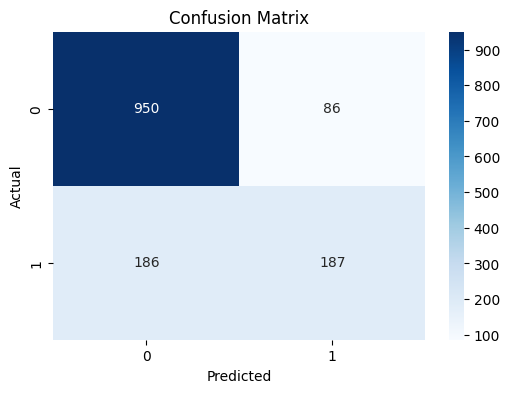

In [17]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

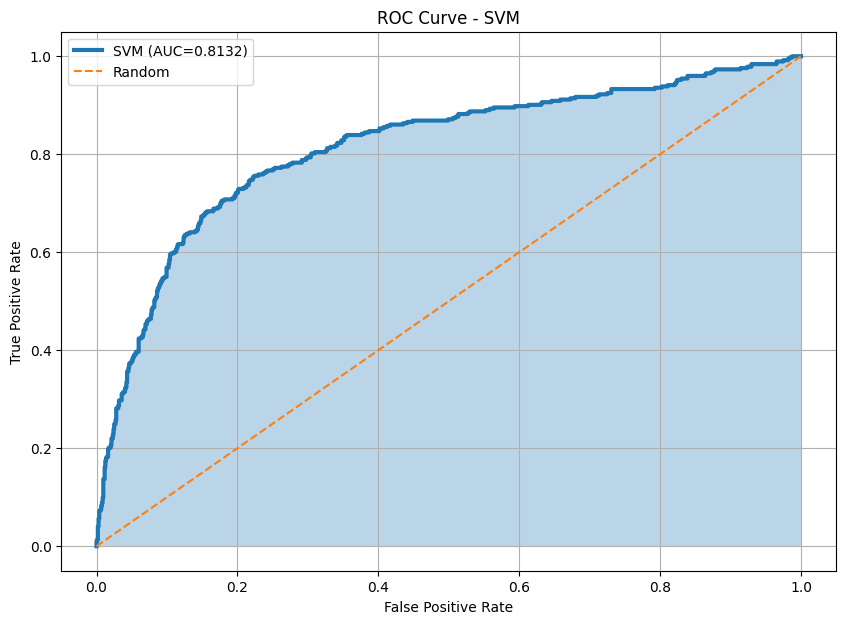

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(10,7))
plt.plot(fpr,tpr,linewidth=3,label=f'SVM (AUC={auc_score:.4f})')
plt.fill_between(fpr,tpr,alpha=0.3)
plt.plot([0,1],[0,1],'--',label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid()
plt.show()

In [19]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

print(results.head(10))

   Actual  Predicted  Probability
0       1          1     0.534457
1       0          0     0.125059
2       0          0     0.137711
3       1          1     0.708111
4       0          0     0.090504
5       1          0     0.163137
6       0          0     0.128780
7       0          0     0.159971
8       1          0     0.175203
9       1          0     0.155117


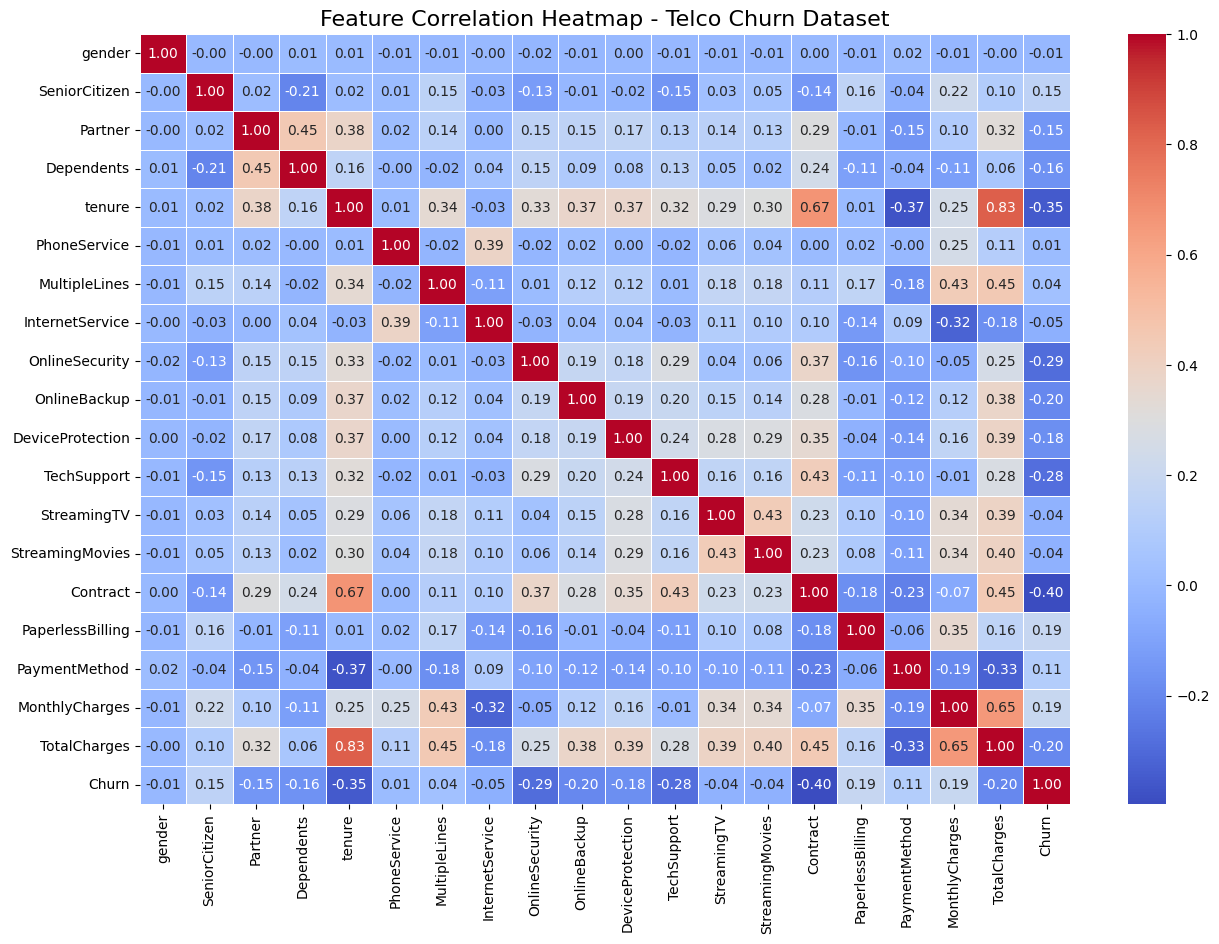

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.corr()


plt.figure(figsize=(15, 10))


sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap - Telco Churn Dataset', fontsize=16)
plt.show()

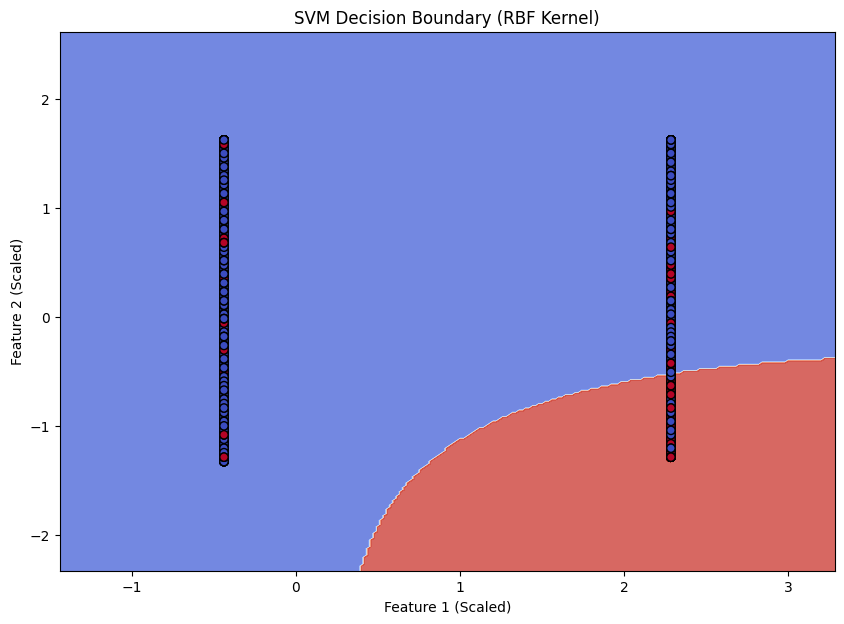

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC


X_vis = X_train[:, [1, 4]]
y_vis = y_train

svm_model = SVC(kernel='rbf', C=1, gamma=0.1)
svm_model.fit(X_vis, y_vis)


h = .02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))


Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)


plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title('SVM Decision Boundary (RBF Kernel)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.show()

<Figure size 1200x1000 with 0 Axes>

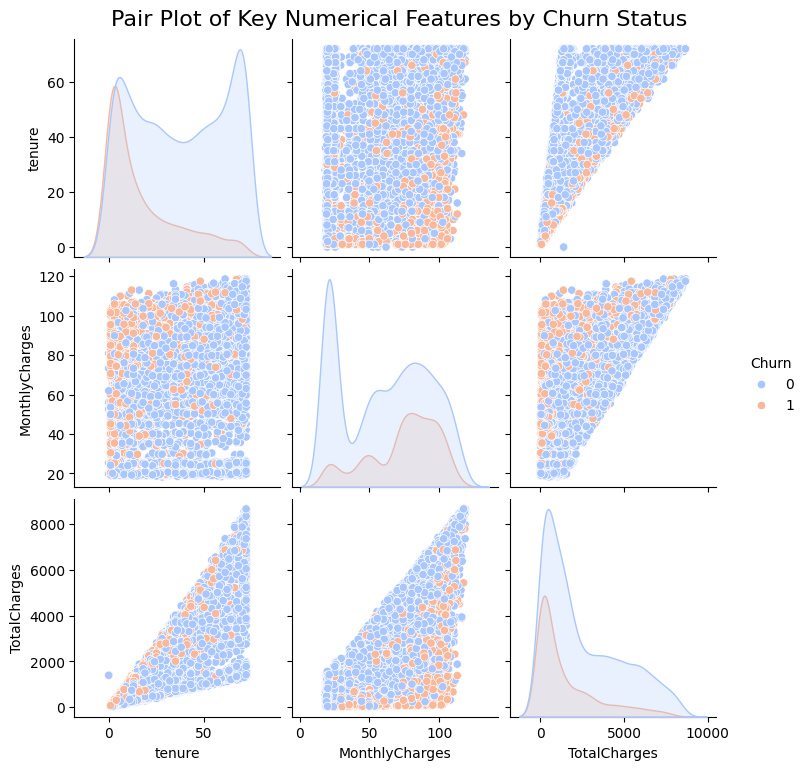

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt


important_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


plt.figure(figsize=(12, 10))
sns.pairplot(df[important_features], hue='Churn', palette='coolwarm', diag_kind='kde')


plt.suptitle('Pair Plot of Key Numerical Features by Churn Status', y=1.02, fontsize=16)
plt.show()